# Lab 11: Corner Detection and Keypoint Matching

**Computer Vision Course**

Today you'll learn how to detect **corners** (keypoints) in images and **match** them between different views — fundamental for image stitching, 3D reconstruction, object tracking, and more!

**What you'll learn:**
- What makes a corner a "good feature to track"
- Harris-Stephens corner detector
- Shi-Tomasi corner detector
- Patch-based keypoint matching
- Handling rotation, noise, and geometric transformations

**What you'll build:**
- Corner detectors using OpenCV
- A patch-based matching algorithm
- Analysis of matching robustness under transformations

**Why this matters:**
Corners are the foundation of many CV applications:
- Image stitching (panoramas)
- 3D reconstruction
- Object tracking
- Visual SLAM (robot navigation)
- Augmented Reality

**Connection to previous labs:**
- Lab 8: Edges mark boundaries, **corners mark distinctive points**
- Lab 9: Scale-space helps find corners at multiple scales
- Lab 10: Convolutional Neural Networks
- Lab 11 (today): Detect and match corners across images
- Future: SIFT, ORB, and learned features build on these ideas!

## Setup

In [3]:
"""
Computer Vision Course - Lab 11: Corner Detection

This cell sets up the environment.
Works automatically for both local and Google Colab!
"""

import os
import sys

# Detect environment
IN_COLAB = 'google.colab' in sys.modules

print("=" * 60)
print("Computer Vision - Lab 11: Corner Detection")
print("=" * 60)

if IN_COLAB:
    print("\n🔵 Running on Google Colab")
    print("-" * 60)

    if not os.path.exists('computer-vision'):
        print("📥 Cloning repository...")
        !git clone https://github.com/mjck/computer-vision.git
        print("✓ Repository cloned successfully")
    else:
        !git -C computer-vision pull
        print("✓ Repository already exists")

    %cd computer-vision/labs/lab11_corners
    print(f"✓ Current directory: {os.getcwd()}")

    sys.path.insert(0, '/content/computer-vision')
    print("✓ Python path configured")

    print("-" * 60)
    print("🟢 Colab setup complete!\n")

else:
    print("\n🟢 Running locally")
    print("-" * 60)
    print(f"✓ Current directory: {os.getcwd()}")

    repo_root = os.path.abspath('../..')
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    print(f"✓ Repository root: {repo_root}")

    print("-" * 60)
    print("🟢 Local setup complete!\n")

print("=" * 60)
print("✅ Environment ready!")
print("=" * 60)

Computer Vision - Lab 11: Corner Detection

🔵 Running on Google Colab
------------------------------------------------------------
📥 Cloning repository...
Cloning into 'computer-vision'...
remote: Enumerating objects: 418, done.
remote: Counting objects: 100% (208/208), done.
remote: Compressing objects: 100% (166/166), done.
remote: Total 418 (delta 105), reused 142 (delta 42), pack-reused 210 (from 1)
Receiving objects: 100% (418/418), 6.24 MiB | 19.41 MiB/s, done.
Resolving deltas: 100% (201/201), done.
Filtering content: 100% (103/103), 28.26 MiB | 19.46 MiB/s, done.
✓ Repository cloned successfully
/content/computer-vision/labs/lab11_corners
✓ Current directory: /content/computer-vision/labs/lab11_corners
✓ Python path configured
------------------------------------------------------------
🟢 Colab setup complete!

✅ Environment ready!


## Import Libraries

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Import course utilities
try:
    from sdx import cv_imread, cv_imshow, cv_grayread
    print("✓ sdx module loaded")
except ImportError as e:
    print(f"❌ Could not import sdx: {e}")
    raise

print("✓ All imports successful")

✓ sdx module loaded
✓ All imports successful


---
## What Is a Corner?

### The Three Cases

When we slide a window over different parts of an image:

1. **Flat region:** No change in any direction
   - Example: Inside a white wall
   - Not useful for matching!

2. **Edge:** Change in one direction only
   - Example: Along a boundary line
   - Can slide along the edge
   - **Ambiguous** — many points look the same

3. **Corner:** Change in **all directions**
   - Example: Building corner, intersection of edges
   - **Unique** — can't slide without big change
   - **Perfect for matching!**

### Why Corners Matter

**Corners are "good features to track"** because:
- ✅ **Distinctive:** Look different from surroundings
- ✅ **Repeatable:** Can find them again in other images
- ✅ **Localized:** Precise position
- ✅ **Stable:** Resistant to small changes (to an extent)

**Applications:**
- Find same point in two photos → stereo vision
- Track point across video frames → motion estimation
- Match photos → image stitching (panoramas)
- Recognize objects → find known patterns

### Corner Detection Algorithms

Today we'll use two classic algorithms:

1. **Harris-Stephens (1988):** Based on eigenvalues of structure tensor
2. **Shi-Tomasi (1994):** Improved version of Harris

Both look for points where intensity changes significantly in multiple directions.

---
## Test Images

We have a **source image** and several **transformed versions** to test matching robustness.

Source image loaded
Shape: (100, 100)


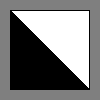

In [5]:
# Load source image
source = cv_grayread('source.png', asfloat=False)

print("Source image loaded")
print(f"Shape: {source.shape}")
cv2_imshow(source)

### Available Test Images

We have multiple transformed versions of the source:

**Rotation tests:**
- `rotation-45.png`, `rotation-90.png`, `rotation-135.png`
- `rotation-180.png`, `rotation-225.png`, `rotation-270.png`, `rotation-315.png`

**Noise test:**
- `noise.png` — source with added noise

**Geometric warping tests:**
- `warp-top.png`, `warp-bottom.png`, `warp-left.png`, `warp-right.png`

**Baseline:**
- `baseline.png` — identical to source (perfect match test)

---
## Part 1: Corner Detection

We'll implement wrappers around OpenCV's corner detectors.

### Harris-Stephens Corner Detector

**The algorithm (simplified):**
1. Compute image gradients (I_x and I_y)
2. For each pixel, build structure tensor M:
   ```
   M = [[Σ(I_x²),  Σ(I_x·I_y)],
        [Σ(I_x·I_y), Σ(Σ(I_y²)]]
   ```
3. Compute corner response: R = det(M) - k·trace(M)²
4. Points with high R are corners

**Parameters:**
- Block size: 3 (window for computing gradients)
- Kernel size: 3 (Gaussian for smoothing)
- k: 0.05 (empirical constant)

We'll keep these fixed to avoid "analysis paralysis"!

In [6]:
def harris_stephens_points(image, limit=None):
    """
    Detect corners using Harris-Stephens algorithm.

    Args:
        image: Input grayscale image (float32, 0-255)
        limit: Maximum number of corners to return (None = all)

    Returns:
        List of (y, x) corner coordinates, sorted by strength
    """
    height, width = image.shape

    # Keep these parameters fixed
    harris = cv2.cornerHarris(image, blockSize=3, ksize=3, k=0.05)

    # Convert response map to list of points
    points = []

    for y in range(height):
        for x in range(width):
            value = harris[y, x]

            # Negative values = edges
            # Zero values = flat regions
            # Positive values = corners
            if value > 0:
                points.append((y, x, value))

    # Sort by corner strength (highest first)
    points.sort(key=lambda point: point[2], reverse=True)

    if limit is None:
        limit = len(points)

    # Return (y, x) without strength value
    return [(y, x) for y, x, value in points][:limit]

print("✓ harris_stephens_points() defined")

✓ harris_stephens_points() defined


### Shi-Tomasi Corner Detector

**Improvement over Harris:**
- Harris uses: R = λ₁·λ₂ - k·(λ₁ + λ₂)²
- Shi-Tomasi uses: R = min(λ₁, λ₂)

Where λ₁, λ₂ are eigenvalues of structure tensor.

**Why better:**
- More stable
- Easier to threshold
- "Good features to track" paper title!

In [7]:
def shi_tomasi_points(image, limit=None):
    """
    Detect corners using Shi-Tomasi algorithm.

    Args:
        image: Input grayscale image (float32, 0-255)
        limit: Maximum number of corners to return (None = all)

    Returns:
        List of (y, x) corner coordinates, sorted by strength
    """
    height, width = image.shape

    # Keep these parameters fixed
    # maxCorners=0 means detect all corners
    gftt = cv2.goodFeaturesToTrack(
        image,
        maxCorners=0,
        qualityLevel=0.01,
        minDistance=0
    )

    # Clean up output format
    points = []
    for point in gftt:
        x, y = point[0]
        points.append((round(y), round(x)))

    if limit is None:
        limit = len(points)

    return points[:limit]

print("✓ shi_tomasi_points() defined")

✓ shi_tomasi_points() defined


### Visualize Detected Corners

In [8]:
def draw_points(image, points, color=(0, 0, 255), radius=4):
    """
    Draw circles at corner locations.

    Args:
        image: Grayscale image
        points: List of (y, x) coordinates
        color: Circle color (B, G, R)
        radius: Circle radius in pixels
    """
    # Convert to BGR for colored drawing
    output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    for y, x in points:
        cv2.circle(output, (x, y), radius, color, 2)

    cv2_imshow(output)

print("✓ draw_points() defined")

✓ draw_points() defined


### Test Corner Detection

Harris-Stephens detected 50 corners (showing top 50)


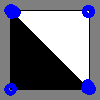


Shi-Tomasi detected 4 corners (showing top 50)


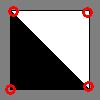


🤔 Notice: Different algorithms detect slightly different corners!


In [9]:
# Detect corners using both algorithms
harris_corners = harris_stephens_points(source, limit=50)
shi_tomasi_corners = shi_tomasi_points(source, limit=50)

print(f"Harris-Stephens detected {len(harris_corners)} corners (showing top 50)")
draw_points(source, harris_corners, color=(255, 0, 0))

print(f"\nShi-Tomasi detected {len(shi_tomasi_corners)} corners (showing top 50)")
draw_points(source, shi_tomasi_corners, color=(0, 0, 255))

print(f"\n🤔 Notice: Different algorithms detect slightly different corners!")

---
## Part 2: Patch-Based Matching

**The idea:** To match corners between images, we compare the **local appearance** around each corner.

**Method:** Extract a small square patch (e.g., 11×11 pixels) around each corner, then compare patches.

✓ patch() function defined

Example patch at corner (12, 13):
Shape: (11, 11)


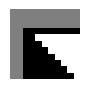

In [10]:
def patch(image, y, x, size):
    """
    Extract a square patch centered at (y, x).

    Args:
        image: Input image
        y, x: Center coordinates
        size: Patch size (must be odd)

    Returns:
        Patch array of shape (size, size)
    """
    radius = size // 2
    return image[(y - radius):(y + radius + 1), (x - radius):(x + radius + 1)]

print("✓ patch() function defined")

# Example: extract and show a patch
if len(harris_corners) > 0:
    y, x = harris_corners[0]
    test_patch = patch(source, y, x, 11)
    print(f"\nExample patch at corner ({y}, {x}):")
    print(f"Shape: {test_patch.shape}")
    cv_imshow(test_patch, figsize=(1,1))

---
## ✏️ Exercise 1: Implement Patch Distance

**Task:** Implement a function to compute the distance between two patches.

**Alternative metrics to consider:**
- Euclidean distance (L2 norm): sqrt(Σ(patch1 - patch2)²)
- Sum of Absolute Differences (SAD): Σ|patch1 - patch2|
- Normalized Cross-Correlation (NCC)

**Instructions:**
1. Implement `calculate_distance(s_patch, t_patch, size)`
2. It should return a single number (the distance)
3. Smaller distance = more similar patches
```

In [11]:
# Sobel filters, copied from Class 7.

from scipy import signal

Dx = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1],
])

Dy = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1],
])

def convolve(input, kernel):
    return signal.correlate2d(input, kernel, mode='valid')

# Function to adjust the patch rotation.

def adjust_rotation(patch, size):
    # Apply Gaussian smoothing.
    patch = cv2.GaussianBlur(patch, (5, 5), 1)

    # Calculate average gradients.
    gradient_x = convolve(patch, Dx).mean()
    gradient_y = convolve(patch, Dy).mean()

    # Calculate the average gradient direction.
    # The first parameter is inverted because
    # the OpenCV vertical axis grows downwards.
    direction = np.arctan2(-gradient_y, gradient_x)
    angle = np.rad2deg(direction)

    # Rotate the patch around its center in
    # order to bring the direction to zero.
    center = size // 2
    color = (127, 127, 127)
    M = cv2.getRotationMatrix2D((center, center), -angle, 1)
    return cv2.warpAffine(patch, M, patch.shape, borderMode=cv2.BORDER_CONSTANT, borderValue=color)

# Function to adjust the patch contrast.

def adjust_contrast(patch):
    min = patch.min()
    max = patch.max()
    return 255 * (patch - min) / (max - min)

def calculate_distance(s_patch, t_patch, size):
    s_patch = adjust_contrast(adjust_rotation(s_patch, size))
    t_patch = adjust_contrast(adjust_rotation(t_patch, size))
    return np.sqrt(np.sum((s_patch - t_patch) ** 2))

def calculate_distance_old(s_patch, t_patch, size):
    """
    Calculate distance between two patches.

    Args:
        s_patch: Source patch (size × size array)
        t_patch: Target patch (size × size array)
        size: Patch size

    Returns:
        Distance value (float)
    """
    # TODO: Implement this!
    diff = s_patch - t_patch
    distance = np.sqrt(np.sum(diff ** 2))
    return distance

    return 0.0  # Replace with your implementation

# ────────────────────────────────────────────────────────────────────────────

print("Implement calculate_distance() above")

Implement calculate_distance() above


### Test Your Distance Function

Once implemented, test it:

In [12]:
# Test: distance between a patch and itself should be 0
if len(harris_corners) > 0:
    y, x = harris_corners[0]
    test_patch = patch(source, y, x, 11)
    dist = calculate_distance(test_patch, test_patch, 11)

    print(f"Distance between patch and itself: {dist:.4f}")
    print("✓ Should be 0.0 (or very close)")

    # Test: distance between different patches should be > 0
    if len(harris_corners) > 1:
        y2, x2 = harris_corners[1]
        test_patch2 = patch(source, y2, x2, 11)
        dist2 = calculate_distance(test_patch, test_patch2, 11)

        print(f"\nDistance between two different patches: {dist2:.4f}")
        print("✓ Should be > 0")

Distance between patch and itself: 0.0000
✓ Should be 0.0 (or very close)

Distance between two different patches: 3.1891
✓ Should be > 0


---
## ✏️ Exercise 2: Implement Keypoint Matching

**Task:** Find matches between corners in two images using patch comparison.

**Algorithm:**
```
For each corner in source image:
    1. Extract patch around source corner
    2. For each corner in target image:
        a. Extract patch around target corner
        b. Calculate distance between patches
    3. Find target corner with minimum distance
    4. If distance < threshold:
        Add (source_corner, target_corner) to matches
```

**Instructions:**
1. Implement `calculate_matches(source, target, s_points, t_points, size, threshold)`
2. Returns list of tuples: [((s_y, s_x), (t_y, t_x)), ...]
3. Only include matches where distance < threshold

**Important:** Handle edge cases — corners too close to image border!

In [13]:
# ── Your code here ──────────────────────────────────────────────────────────

def calculate_matches(source, target, s_points, t_points, size, threshold):
    """
    Find matches between corners in two images.

    Args:
        source: Source image
        target: Target image
        s_points: List of (y, x) corners in source
        t_points: List of (y, x) corners in target
        size: Patch size for comparison
        threshold: Maximum distance for accepting a match

    Returns:
        List of matching pairs: [((s_y, s_x), (t_y, t_x)), ...]
    """
    matches = []
    radius = size // 2
    s_height, s_width = source.shape
    t_height, t_width = target.shape

    # TODO: Implement matching algorithm
    # For each source corner:
    #   1. Check if patch is within image bounds
    #   2. Extract source patch
    #   3. For each target corner:
    #       a. Check if patch is within image bounds
    #       b. Extract target patch
    #       c. Calculate distance
    #   4. Find best match (minimum distance)
    #   5. If distance < threshold, add to matches

    # Hint: Use your calculate_distance() function
    # Hint: Check bounds: y >= radius and y < height - radius
    for s_y, s_x in s_points:
        # Check if source patch is within bounds
        if (s_y < radius or s_y >= s_height - radius or
            s_x < radius or s_x >= s_width - radius):
            continue

        # Extract source patch
        s_patch = patch(source, s_y, s_x, size)

        # Find best matching target corner
        best_distance = float('inf')
        best_match = None

        for t_y, t_x in t_points:
            # Check if target patch is within bounds
            if (t_y < radius or t_y >= t_height - radius or
                t_x < radius or t_x >= t_width - radius):
                continue

            # Extract target patch
            t_patch = patch(target, t_y, t_x, size)

            # Calculate distance
            distance = calculate_distance(s_patch, t_patch, size)

            # Track best match
            if distance < best_distance:
                best_distance = distance
                best_match = (t_y, t_x)

        # Add match if below threshold
        if best_match is not None and best_distance < threshold:
            matches.append(((s_y, s_x), best_match))

    return matches

# ────────────────────────────────────────────────────────────────────────────

### Visualize Matches

In [14]:
def draw_matches(source, target, matches):
    """
    Draw lines connecting matched corners between two images.

    Args:
        source: Source image
        target: Target image
        matches: List of ((s_y, s_x), (t_y, t_x)) tuples
    """
    s_height, s_width = source.shape
    t_height, t_width = target.shape

    # Create combined image (source | target)
    height = max(s_height, t_height)
    shift = s_width + 1  # Gap between images
    width = shift + t_width

    # White background
    combined = np.full((height, width), 127, np.float32)
    combined[:s_height, :s_width] = source
    combined[:t_height, shift:width] = target

    # Convert to BGR for colored lines
    combined = cv2.cvtColor(combined, cv2.COLOR_GRAY2BGR)

    # Draw lines for each match
    for (s_y, s_x), (t_y, t_x) in matches:
        cv2.line(
            combined,
            (s_x, s_y),              # Source point
            (shift + t_x, t_y),      # Target point (shifted)
            (0, 255, 0),             # Green
            1
        )

    cv2_imshow(combined)

print("✓ draw_matches() defined")

✓ draw_matches() defined


---
## Part 3: Test Matching Under Different Transformations

Once you've implemented the matching function, test it!

### Test 1: Baseline (Perfect Match)

Baseline is identical to source — should get perfect matches!

Testing on baseline (identical image):

Found 4 matches


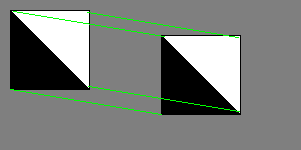

In [15]:
# Load baseline image
baseline = cv_grayread('baseline.png', asfloat=False)

# Detect corners
baseline_corners = shi_tomasi_points(baseline, limit=50)

print("Testing on baseline (identical image):\n")

# Match with patch size 11, threshold 30
matches = calculate_matches(
    source, baseline,
    shi_tomasi_corners[:50], baseline_corners,
    size=11,
    threshold=30.0
)

print(f"Found {len(matches)} matches")

draw_matches(source, baseline, matches)

### Test 2: Rotation

How does matching perform under rotation?

Testing rotations:

Rotation 45°: 4 matches


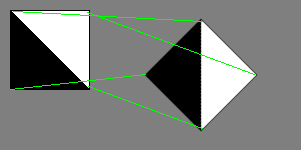

Rotation 90°: 4 matches


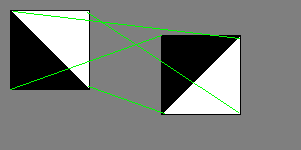

Rotation 135°: 4 matches


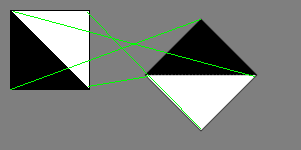

Rotation 180°: 4 matches


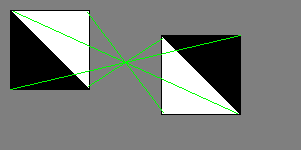

Rotation 225°: 4 matches


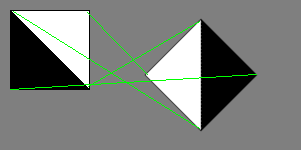

Rotation 270°: 4 matches


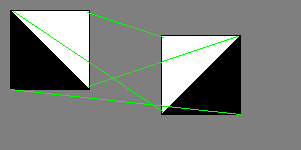

Rotation 315°: 4 matches


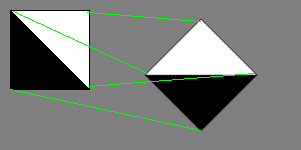

In [16]:
# Test different rotations
rotations = [45, 90, 135, 180, 225, 270, 315]

print("Testing rotations:\n")

for angle in rotations:
    # Load rotated image
    rotated = cv_grayread(f'rotation-{angle}.png', asfloat=False)
    rotated_corners = shi_tomasi_points(rotated, limit=50)

    # Find matches
    matches = calculate_matches(
        source, rotated,
        shi_tomasi_corners[:50], rotated_corners,
        size=11,
        threshold=30.0
    )

    print(f"Rotation {angle}°: {len(matches)} matches")
    draw_matches(source, rotated, matches)

### Test 3: Noise

How robust is matching to noise?

Testing with noise:

Found 4 matches
How many do you expect?


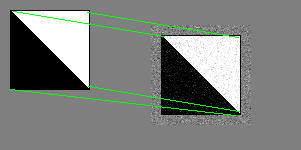

In [17]:
# Load noisy image
noisy = cv_grayread('noise.png', asfloat=False)
noisy_corners = shi_tomasi_points(noisy, limit=50)

print("Testing with noise:\n")

matches = calculate_matches(
    source, noisy,
    shi_tomasi_corners[:50], noisy_corners,
    size=11,
    threshold=30.0
)

print(f"Found {len(matches)} matches")
print("How many do you expect?")

draw_matches(source, noisy, matches)

### Test 4: Geometric Warping

Perspective and affine transformations are common in real applications.

Testing geometric warping:

Warp top: 4 matches


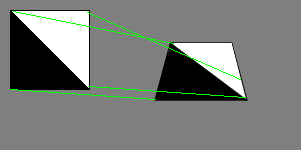

Warp bottom: 4 matches


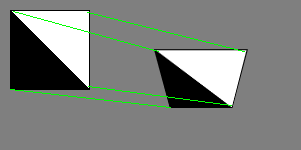

Warp left: 4 matches


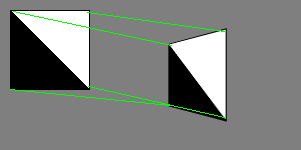

Warp right: 4 matches


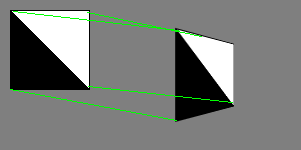


✓ Patch matching handles small warping reasonably well!


In [18]:
# Test all warp directions
warps = ['top', 'bottom', 'left', 'right']

print("Testing geometric warping:\n")

for direction in warps:
    # Load warped image
    warped = cv_grayread(f'warp-{direction}.png', asfloat=False)
    warped_corners = shi_tomasi_points(warped, limit=50)

    # Find matches
    matches = calculate_matches(
        source, warped,
        shi_tomasi_corners[:50], warped_corners,
        size=11,
        threshold=30.0
    )

    print(f"Warp {direction}: {len(matches)} matches")
    draw_matches(source, warped, matches)

print("\n✓ Patch matching handles small warping reasonably well!")

---
## Part 4: Analysis and Limitations

### What We Learned

**✅ What works:**
- Baseline (identical images) → Perfect matches
- Small transformations → Good matches
- Moderate noise → Reasonable robustness
- Small geometric warping → Handles well

**❌ What doesn't work:**
- Large rotations → Fails completely
- Simple patch comparison is **not rotation-invariant**

### Beyond Basic Patch Matching

Modern algorithms improve on what we built today:

**SIFT (1999):**
- Scale-invariant (uses DoG pyramid from Lab 9!)
- Rotation-invariant (computes dominant orientation)
- Distinctive descriptor (128-dim vector)

**SURF (2006):**
- Faster approximation of SIFT
- Uses integral images

**ORB (2011):**
- Very fast (uses FAST corners + BRIEF descriptor)
- Rotation-invariant (computes orientation)
- Free and open-source

**Learned features (2010s):**
- SuperPoint, D2-Net, R2D2
- Neural networks learn descriptors
- Even more robust!

### Connection to Previous Labs

**Lab 8 (Derivatives):**
- Corners are where both I_x and I_y are large
- Harris uses eigenvalues of [[I_x², I_xI_y], [I_xI_y, I_y²]]

**Lab 9 (Scale Space):**
- SIFT detects corners at multiple scales
- Uses DoG pyramid for scale-invariance

**Lab 11 (today):**
- Basic corner detection and matching
- Foundation for more advanced methods

### ✏️ Final Reflection (+1 point)

Answer these questions:

1. **Why are corners better than edges for matching?**

2. **Why does simple patch matching fail on rotated images?**

3. **What would you need to add to make matching rotation-invariant?**

4. **How does this lab connect to SIFT (from Lab 9's scale-space)?**

In [ ]:
# Your reflection:

# 1. Why corners over edges?
#    ...

# 2. Why rotation fails?
#    ...

# 3. How to fix rotation?
#    ...

# 4. Connection to SIFT?
#    ...
